# CSE2530 Computational Intelligence
## Assignment 3: Reinforcement Learning

<div>
    
|    Group   |           1          |
|------------|----------------------|
| Junhan Chong  |        6153283       |
| Jack Bergmann  |        6200850       |
| Madhav Tiwari  |        6141870       |
| Ben Chen  |        6543405       |

#### Imports

In [1]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from typing import Dict, List
from tqdm import tqdm

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Agent import Agent
from Maze import Maze
from QTable import QTable
from State import State
from Action import Action

## 2. Navigating in the Supermarket
### 2.1 Development
#### Question 1

In [2]:
class ExplorationStrategy:
    def __init__(self, q_table: QTable):
        self.q_table = q_table

    def random(self, agent: Agent, maze: Maze):
        """
        The random exploration strategy selects a random action uniformly at random
        from the set of all valid actions.
        """
        # find all possible actions for the particular state that the agent is in
        valid_as = agent.get_valid_actions(maze)
        # choose an action from the list of valid actions randomly, with uniform distribution
        chosen_action = np.random.choice(valid_as)
        # take the chosen action
        return chosen_action

        


    def e_greedy(self, agent: Agent, maze: Maze, eps: float):
        """
        The e-greedy exploration strategy selects a random action with probability eps
        and the action with highest q-value with probability 1 - eps. A value of epsilon
        close to 0 favours exploitation, while a value close to 1 favours exploration.
        """
        # find all possible actions for the particular state that the agent is in
        valid_as = agent.get_valid_actions(maze)
        s = agent.get_state(maze)

        # find the corresponding q values for the possible actions
        q_vals = [self.q_table.get_q(s, a) for a in valid_as]

        # find the actions with largest q value(s)
        max_q = np.max(q_vals)
        max_q_actions = [a for a, q in zip(valid_as, q_vals) if q == max_q]

        chosen_action = None
        # with probability of 1 - eps, select randomly from actions with the largest q values
        if (np.random.uniform() > eps):
            chosen_action = np.random.choice(max_q_actions)
        # with probability of eps, select randomly from the list of possible actions
        else:
            not_max = [a for a in valid_as if a not in max_q_actions]
            if len(not_max) == 0:
                chosen_action = np.random.choice(valid_as)
            else:
                chosen_action = np.random.choice(not_max)
        # take the chosen action
        return chosen_action



    def boltzmann(self, agent: Agent, maze: Maze, temperature: float):
        """
        The Boltzmann exploration strategy assigns a probability to each action based on its estimated q-values.
        A large value of the temperature encourages exploration and as the temperature declines over time,
        exploitation is favoured. 
        """
        # find all possible actions for the particular state that the agent is in
        valid_as = agent.get_valid_actions(maze)
        s = agent.get_state(maze)

        # find the corresponding q values for the possible actions
        q_vals = [self.q_table.get_q(s, a) for a in valid_as]
        # subtract max q val for numerical stability
        q_vals = np.array(q_vals)
        q_vals = q_vals - np.max(q_vals)

        # guard against zero-division
        if temperature <= 0:
            # apply greedy if temperature is zero
            max_q = np.max(q_vals)
            max_q_actions = [a for a, q in zip(valid_as, q_vals) if q == max_q]
            chosen_action = np.random.choice(max_q_actions)
            return chosen_action

        # calculate exp(Q(s,a) / T) for all possible actions
        boltzmann_probs = np.exp(q_vals / temperature)

        # find the sum and divide each term by the sum
        boltzmann_probs /= np.sum(boltzmann_probs)

        
        # choose an action with the boltzmann probabilities as the weights
        chosen_action = np.random.choice(valid_as, p=boltzmann_probs)

        # take the chosen action
        return chosen_action

<div>

**Explain what you did, including the initial selection of the hyper-parameter values. How do you deal with exploration/exploitation tradeoff?**

All three strategies start with finding the valid actions that the agent can take at its current state. This is because the probability of choosing an invalid action should be zero in all given strategies.

For random exploration, I chose an action randomly based on an uniform distribution between the available actions. There are no hyper-parameters for this strategy because all decisions are made with a random uniform probability between actions. Therefore, this exploration strategy would be used initially to maximise exploration while neglecting exploitation.

For $\epsilon$-greedy exploration, I found the corresponding Q values for the possible actions to use for the greedy property of this strategy. With the Q values, we can simply choose the action with the highest associated Q value by definition. However, this approach would only use exploitation without the use of exploration since at any given point, the agent deterministically chooses what action to take. Therefore, we introduce a hyperparameter: $\epsilon$, to introduce exploration. Increasing $\epsilon$ increases exploration by increasing the probability of a random action being chosen, naturally decreasing exploitation as well. Therefore, we must find a suitable value of $\epsilon$ to achieve a good balance of exploitation and exploration in order to avoid convergence at a local optima, while keeping the learning relatively fast and efficient.

For Boltzmann exploration, we assign weights to the different actions to be used as the probability distribution. After finding the corresponding Q values for all possible actions, we use the softmax formula to assign probabilities for the actions. However, just by using the softmax function to assign weights for probability means we cannot tune the strategy to encourage or discourage more exploitation. Therefore, we introduce a hyperparameter $\tau$ (true Boltzmann exploration) which influences the probability of all possible actions. As we increase $\tau$, the probabilities decrease exponentially to its magnitude (because of the exponentiation). Hence, decreasing $\tau$ leads to more exploitation (as the higher Q value actions would be assigned a larger the probability relative to the lower Q value actions) while increasing it will even out the probability distribution towards uniform distribution; As $\tau$ approaches the limit of 0, the approach becomes greedier and greedier, while $T$ approaching infinity would make the strategy choose actions from a uniform distribution.

In practice, we should choose hyperparameters that encourage exploration (large $\epsilon$, large $\tau$) initially, so the agent can learn about the environment and map out a sensible Q table. As the agent explores, we can decrease the hyperparameters to favour more and more exploitation.

Hence, we can use Boltzmann exploration with a large value of $\tau$ initially to encourage exploration, then gradually 'decay' the temperature over each episode until it reaches a threshold to increase exploitation gradually. Since we have four actions per state, with a reward of 10 at the terminal state (initially), our Q values will not be larger than 10. Therefore, we can choose a relatively small value for the temperature, such as $\tau = 1$. Then we can use a fixed percentage value such as 0.99 to slowly decay the temperature over episodes. These hyper-parameters can be optimised during training (with the validation set) to maximise efficiency while minimising the risk of early convergence at a local optima.

#### Question 2

In [3]:
# Create a Maze instance.
easy_maze = Maze("./../data/easy_maze.txt")
easy_maze.set_reward(x = 9, y = 9, reward = 10)
easy_maze.set_terminal(x = 9, y = 9)

def main_no_learn(maze, n_episodes = 300, alpha = 0.1, discount = 0.9, decay = 0.99, temperature = 1):
    # Hyper-parameters.
    episode_lengths = []
    episode_rewards = []

    # Create an Agent.
    agent = Agent(start_x=0, start_y=0)
    # Create a QTable.
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    # Create an ExplorationStrategy.
    exploration_strategy = ExplorationStrategy(q_table)
    # Create a learner.
    params = {"lr": 0.7, "gamma": 0.9}
    # learner = QLearning(q_table, params)

    
    # repeat exploration #n_episodes amount of time
    for episode in tqdm(range(n_episodes)):
        # put agent at the start
        agent.reset()

        #counter to check progress
        steps = 0
        total_r = 0

        # explore until terminal state
        while (agent.get_state(maze).done == False):
            # one exploration step
            current_state = agent.get_state(maze)
            chosen_action = exploration_strategy.boltzmann(agent, maze, temperature)
            next_state, r, done = agent.step(chosen_action, maze)

            ## updating Q table is the learner's job ##

            # variables for Q table update calculations
            # q_old = q_table.get_q(current_state, chosen_action)
            # q_max_new = np.max([q_table.get_q(next_state, a) for a in agent.get_valid_actions(maze)])

            # update Q table
            # q_table.set_q(current_state, chosen_action, 
                        # q_old + alpha * (r + discount * q_max_new - q_old))
            
            # re-assign/increment control variables
            current_state = next_state
            total_r += r
            steps += 1
        
        # decay the temperature every episode
        temperature *= decay

        # append progress variables to progress tracker
        episode_rewards.append(total_r)
        episode_lengths.append(steps)


<div>

**Explain the cycle in your report.**

The cycle consists of three steps until the agent reaches a terminal state:
1. **Take action step:** We decide on the action for the agent to take. We used the Boltzmann strategy, with an initial temperature of 1.0. We then take the chosen action, getting the new state and reward for the action (at the particular state) as a return value. <br>
*\<This step is necessary for the agent to explore the environment\>*
2. **Update Q table:** We take the Q values of the initial state and action that we've chosen, as well as the Q values for max state-action value for the next state. Using these, we calculate the new Q value for the initial state-action pair. <br>
*\<This step is necessary to learn the environment. Q table is what is used to exploit efficient paths\>*
3. **Update states and reward metrics:** We then update the current state variable to the new position of the agent, as well as incrementing the rewards and step count to use as a performance metric. <br>
*\<This step is necessary to evaluate progress and allow for a cycle\>*

This cycle can be repeated until the agent reaches the terminal state, at which a new episode will start. These three steps are sufficient for a complete trial/episode (agent exploring from the start to terminal state) as it can explore the environment and learn from it (Q table). Repeating this cycle over the episodes will lead to a convergence in the Q value according to the **Stochastic Approximation Theory**. Then we can improve the policy based on the values from the Q table.

#### Question 3

In [4]:
def main_early_stop_no_learn(maze, n_episodes = 300, decay = 0.99, temperature = 1, early_stop = 30000):
    # Hyper-parameters.
    episode_lengths = []
    episode_rewards = []

    # Create an Agent.
    agent = Agent(start_x=0, start_y=0)

    # Create a QTable
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    
    # Create an ExplorationStrategy
    exploration_strategy = ExplorationStrategy(q_table)

    # global step tracker
    total_steps = 0
    episodes = 0

    # repeat exploration #n_episodes amount of time
    for episode in range(n_episodes):
        # put agent at the start
        agent.reset()

        #counter to check progress
        steps = 0
        total_r = 0

        # explore until terminal state
        while (agent.get_state(maze).done == False):
            if (total_steps >= early_stop):
                break
            ## STEP 1: TAKE STEP ##
            current_state = agent.get_state(maze)
            chosen_action = exploration_strategy.boltzmann(agent, maze, temperature)
            next_state, r, done = agent.step(chosen_action, maze)

            ## STEP 2: UPDATE Q TABLE / LEARN ##
            
            ## STEP 3: RECORD STATE AND REWARDS ##
            # re-assign/increment control variables
            current_state = next_state
            total_r += r
            steps += 1
            total_steps += 1
        
        # decay the temperature every episode
        temperature *= decay

        # append progress variables to progress tracker
        episode_rewards.append(total_r)
        episode_lengths.append(steps)

        episodes += 1
        print(f"{ steps } steps at episode { episodes }")

        if (total_steps >= early_stop):
            print(f"{ total_steps } steps reached. Terminating current episode.")
            print(f"Stopped at episode number: { episodes }")
            break
        
    return episode_lengths

In [5]:
main_early_stop_no_learn(easy_maze)

5730 steps at episode 1
1248 steps at episode 2
354 steps at episode 3
3628 steps at episode 4
12848 steps at episode 5
1242 steps at episode 6
3274 steps at episode 7
1676 steps at episode 8
30000 steps reached. Terminating current episode.
Stopped at episode number: 8


[5730, 1248, 354, 3628, 12848, 1242, 3274, 1676]

<div>

We introduced a global step counter that gets incremented at every step. Since there are two loops, with the outer loop iterating over the episodes and the inner loop iterating over the cycles, we include a break statement in both blocks to ensure that the cycle and the episode are both terminated once reaching 30,000 steps. To verify, we included two simple print statements printing some meta data about the runs (number of episodes, total steps).

We can also note from the steps per episode, that there is a very large variance between episodes, ranging from 100 to over 10,000 steps per episode. There also doesn't seem to be a clear decrease in the number of steps per episode. This is expected as we have not implemented the learning function.

#### Question 4

In [6]:
toy_maze = Maze("./../data/toy_maze.txt")
toy_maze.set_reward(x = 9, y = 9, reward = 10)
toy_maze.set_terminal(x = 9, y = 9)

def run_multiple_no_learn(maze, n_runs = 10, early_stop = 30000):
    all_runs = []

    for i in range(n_runs):
        episode_lengths = main_early_stop_no_learn(
            maze, early_stop
        )
        all_runs.append(episode_lengths)

    return all_runs


def plot_average_episode_lengths(all_runs, difficulty, learning_type = "None"):
    # find max number of episodes across runs
    max_len = max(len(run) for run in all_runs)

    # pad runs with NaN so they all have equal length
    padded_runs = []
    for run in all_runs:
        padded = run + [np.nan] * (max_len - len(run))
        padded_runs.append(padded)

    padded_runs = np.array(padded_runs)

    # compute mean ignoring NaNs
    avg_lengths = np.nanmean(padded_runs, axis=0)
    stds = np.nanstd(padded_runs, axis=0)
    epochs = np.arange(len(avg_lengths)) # for axis labelling with no .5s

    # plot
    plt.figure()
    plt.plot(epochs, avg_lengths, label="Average")
    plt.fill_between(
        epochs,
        np.maximum(avg_lengths - stds, 0),
        avg_lengths + stds,
        alpha=0.3
    )
    plt.xlabel("Episode")
    plt.ylabel("Average Steps per Episode")
    if learning_type == "None":
        plt.title(f"Average episode length over runs in { difficulty } maze")
    else:
        plt.title(f"Average episode length over runs in { difficulty } maze using {learning_type}")
    plt.show()




1006 steps at episode 1
276 steps at episode 2
1392 steps at episode 3
3014 steps at episode 4
394 steps at episode 5
762 steps at episode 6
172 steps at episode 7
728 steps at episode 8
1134 steps at episode 9
1926 steps at episode 10
396 steps at episode 11
336 steps at episode 12
376 steps at episode 13
1132 steps at episode 14
1130 steps at episode 15
1678 steps at episode 16
1076 steps at episode 17
634 steps at episode 18
534 steps at episode 19
2776 steps at episode 20
4586 steps at episode 21
1590 steps at episode 22
1576 steps at episode 23
406 steps at episode 24
284 steps at episode 25
670 steps at episode 26
16 steps at episode 27
30000 steps reached. Terminating current episode.
Stopped at episode number: 27
1170 steps at episode 1
340 steps at episode 2
2552 steps at episode 3
2558 steps at episode 4
1226 steps at episode 5
780 steps at episode 6
284 steps at episode 7
746 steps at episode 8
402 steps at episode 9
1512 steps at episode 10
1334 steps at episode 11
652 step

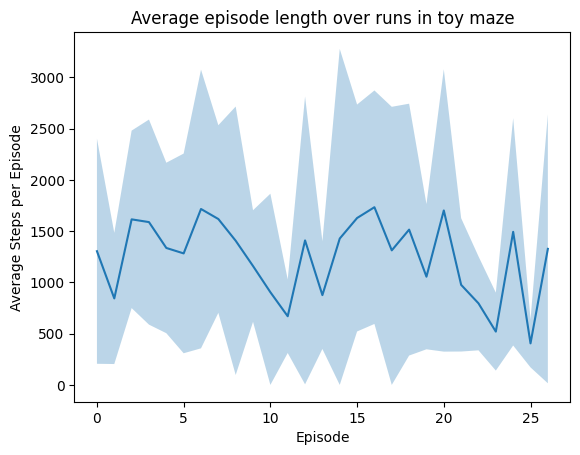

1722 steps at episode 1
3900 steps at episode 2
238 steps at episode 3
1178 steps at episode 4
6292 steps at episode 5
3386 steps at episode 6
254 steps at episode 7
82 steps at episode 8
12948 steps at episode 9
30000 steps reached. Terminating current episode.
Stopped at episode number: 9
2550 steps at episode 1
1574 steps at episode 2
11336 steps at episode 3
280 steps at episode 4
1992 steps at episode 5
2520 steps at episode 6
826 steps at episode 7
7768 steps at episode 8
146 steps at episode 9
206 steps at episode 10
470 steps at episode 11
332 steps at episode 12
30000 steps reached. Terminating current episode.
Stopped at episode number: 12
114 steps at episode 1
3154 steps at episode 2
618 steps at episode 3
2164 steps at episode 4
352 steps at episode 5
398 steps at episode 6
11272 steps at episode 7
6908 steps at episode 8
534 steps at episode 9
1080 steps at episode 10
1680 steps at episode 11
1164 steps at episode 12
74 steps at episode 13
488 steps at episode 14
30000 st

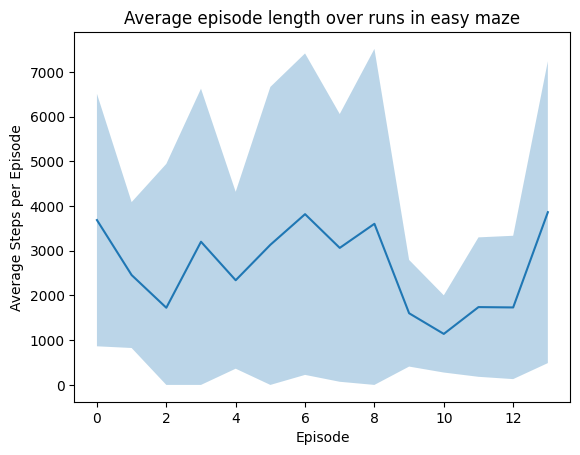

In [7]:
plot_average_episode_lengths(run_multiple_no_learn(toy_maze, early_stop=100000), "toy")
plot_average_episode_lengths(run_multiple_no_learn(easy_maze, early_stop=300000), "easy")

<div>

The plot shows that there is no clear downwards trend for each consecutive episodes in the average over all runs. This indicates that the agent does not take more efficient paths over episode progression due to the lack of learning (updating of the Q table).
Towards the ends of the runs, the average is calculated from fewer values than earlier because some runs might terminate earlier. Therefore, there may be an increased volatility that makes it look like the plot is showing certain trends.

#### Question 5

In [8]:
class QLearning:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params

    def learn(self, possible_actions: List[Action], state: State, action: Action,
               next_state: State, reward: int, done: bool) -> None:
        # variables for Q table update calculations
        q_old = self.q_table.get_q(state, action)
        q_max_new = np.max([self.q_table.get_q(next_state, a) for a in possible_actions])

        # update Q table
        self.q_table.set_q(state, action, 
                    q_old + self.params["lr"] * (reward + self.params["gamma"] * q_max_new - q_old))

In [9]:
class SARSA:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params
    
    def learn(self, state: State, action: Action, next_state: State, next_action: Action,
               reward: float, done: bool) -> None:
        # variables for Q table update calculations
        q_old = self.q_table.get_q(state, action)
        q_new = self.q_table.get_q(next_state, next_action)

        # update Q table
        self.q_table.set_q(state, action, 
                    q_old + self.params["lr"] * (reward + self.params["gamma"] * q_new - q_old))

<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

#### Question 6

In [10]:
def main_early_stop(maze, n_episodes = 300, params = {"lr": 0.7, "gamma": 0.9}, decay = 0.99, eps = 0.0, temperature = 1, early_stop = 30000, q_learning=True, strategy="boltzmann"): # 
    # Hyper-parameters.
    episode_lengths = []
    episode_rewards = []

    # Create an Agent.
    agent = Agent(start_x=0, start_y=0)

    # Create a QTable
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    
    # Create an ExplorationStrategy
    exploration_strategy = ExplorationStrategy(q_table)

    # Create a learner
    if (q_learning):
        learner = QLearning(q_table, params)
    else:
        learner = SARSA(q_table, params)

    # global step tracker
    total_steps = 0
    episodes = 0

    # repeat exploration #n_episodes amount of time
    for episode in range(n_episodes):
        # put agent at the start
        agent.reset()

        #counter to check progress
        steps = 0
        total_r = 0

        # explore until terminal state
        while (agent.get_state(maze).done == False):
            if (total_steps >= early_stop):
                break
            # one exploration step
            current_state = agent.get_state(maze)
            if strategy == "random":
                chosen_action = exploration_strategy.random(agent, maze)
            elif strategy == "e_greedy":
                chosen_action = exploration_strategy.e_greedy(agent, maze, eps)
            elif strategy == "boltzmann":
                chosen_action = exploration_strategy.boltzmann(agent, maze, temperature)
            else:
                chosen_action = exploration_strategy.boltzmann(agent, maze, temperature)
            next_state, r, done = agent.step(chosen_action, maze)
                
            # variables for Q table update calculations
            if (q_learning):
                learner.learn(agent.get_valid_actions(maze), current_state, chosen_action, next_state, r, done)
            else:
                next_action = exploration_strategy.boltzmann(agent, maze, temperature)
                learner.learn(current_state, chosen_action, next_state, next_action, r, done)

            # re-assign/increment control variables
            current_state = next_state
            total_r += r
            steps += 1
            total_steps += 1
        
        # decay the temperature every episode
        temperature *= decay

        # append progress variables to progress tracker
        episode_rewards.append(total_r)
        episode_lengths.append(steps)

        episodes += 1
        # print(f"{ steps } steps at episode { episodes }")

        if (total_steps >= early_stop):
            # print(f"{ total_steps } steps reached. Terminating current episode.")
            # print(f"Stopped at episode number: { episodes }")
            break
        
    return episode_lengths

def run_multiple_q(maze, n_runs = 10, params = {"lr": 0.7, "gamma": 0.9}, decay = 0.99, eps = 0.1, temperature = 1, early_stop = 30000, q_learning=True, strategy="boltzmann"):
    all_runs = []

    for i in range(n_runs):
        episode_lengths = main_early_stop(
            maze, early_stop = early_stop, q_learning = q_learning, strategy = strategy, eps = eps, temperature = temperature, decay = decay, params = params
        )
        all_runs.append(episode_lengths)

    return all_runs


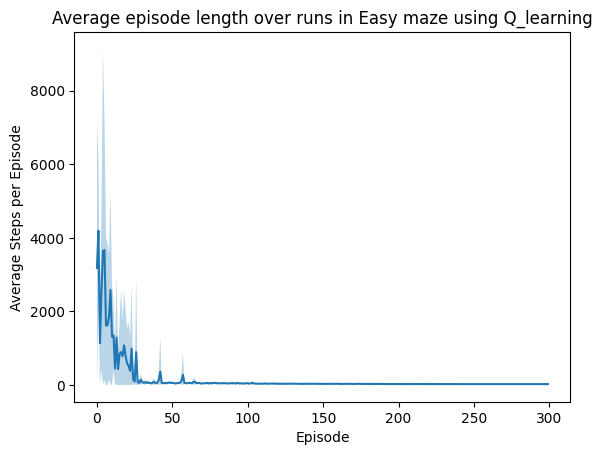

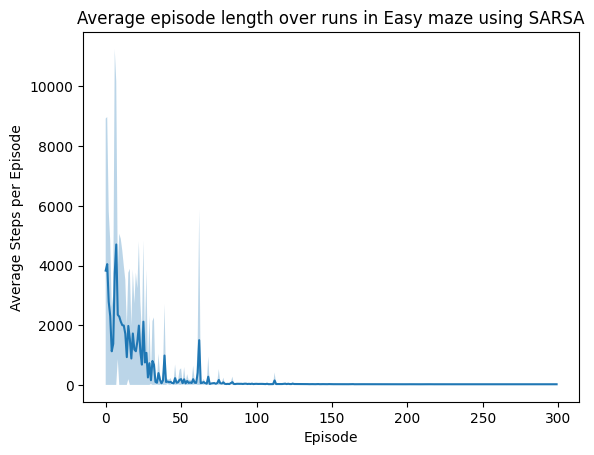

In [11]:
plot_average_episode_lengths(run_multiple_q(easy_maze, early_stop=500000), "Easy", learning_type="Q_learning")
plot_average_episode_lengths(run_multiple_q(easy_maze, early_stop=500000, q_learning = False), "Easy", learning_type="SARSA")

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 7

<div style="background-color:#f1be3e">

_Write your answer here._

### 2.2 Optimization
#### Question 8

In [12]:
def plot_comparison(all_data_dict, title):
    plt.figure()
    for label, all_runs in all_data_dict.items():
        max_len = max(len(run) for run in all_runs)
        padded = [run + [np.nan] * (max_len - len(run)) for run in all_runs]
        padded = np.array(padded)
        avg = np.nanmean(padded, axis=0)
        std = np.nanstd(padded, axis=0)
        epochs = np.arange(len(avg))

        plt.plot(epochs, avg, label=label)
        plt.fill_between(epochs, np.maximum(avg - std, 0), avg + std, alpha=0.2)

    plt.xlabel("Episode")
    plt.ylabel("Average Steps per Episode")
    plt.title(title)
    plt.ylim(0, 4000)
    plt.xlim(0, 50)
    plt.legend()
    plt.show()

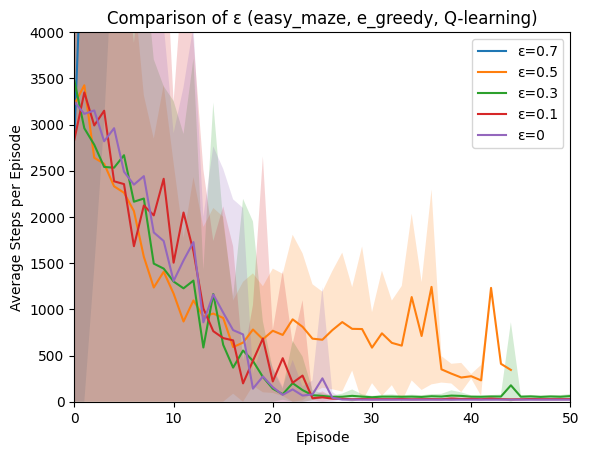

In [13]:
all_data = {}

for eps in [0.7, 0.5, 0.3, 0.1, 0]:
    all_data[f"ε={eps}"] = run_multiple_q(easy_maze, early_stop=30000, strategy="e_greedy", eps=eps, n_runs=100)

plot_comparison(all_data, "Comparison of ε (easy_maze, e_greedy, Q-learning)")

# epsilons = [0, 0.05, 0.1, 0.3, 0.5]

# for eps in epsilons:
#     data = run_multiple_q(toy_maze, early_stop=30000, strategy="e_greedy", eps=eps)
#     plot_average_episode_lengths(data, "toy", learning_type=f"e-greedy ε={eps} in Q-learning")

As shown in the plot, e-greedy fails to converge when e = 0.7 due to its high degree of randomness in its action. Make it unable to exploit effectively along q-table.

In the early episodes, the other four cases (e = 0, 0.1, 0.3, 0.5) converge at a comparable rate. With very low and consistent amount of steps, e = 0, 0.1, 0.3 all perform well, with e = 0    reaching the lowest. e = 5 did shows some early sign of faster convergence indicates the advantage of random explorations in early stage. However, without more runs, we are unable to completely rule out the possibility that it can be an irrelevant anomaly. 

Overall, lower e values lead to better performance with sufficient amount of episodes. Given that the environment in easy maze is not complicated enough to require extensive exploration in order to avoid local optima. The advantage of higher e values require a much complicated environment to discover.

#### Question 9

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 10

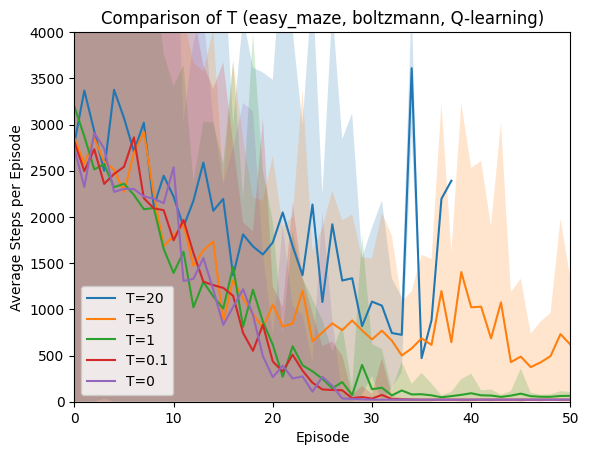

In [14]:
all_data = {}

for t in [20, 5, 1, 0.1, 0]:
    all_data[f"T={t}"] = run_multiple_q(easy_maze, early_stop=50000, strategy="boltzmann", temperature=t, n_runs=100)

plot_comparison(all_data, "Comparison of T (easy_maze, boltzmann, Q-learning)")

# temperatures = [0.1, 0.5, 1, 5, 20]

# for t in temperatures:
#     data = run_multiple_q(toy_maze, early_stop=30000, strategy="boltzmann", temperature=t)
#     plot_average_episode_lengths(data, "toy", learning_type=f"Boltzmann T={t} in Q-learning")

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 11

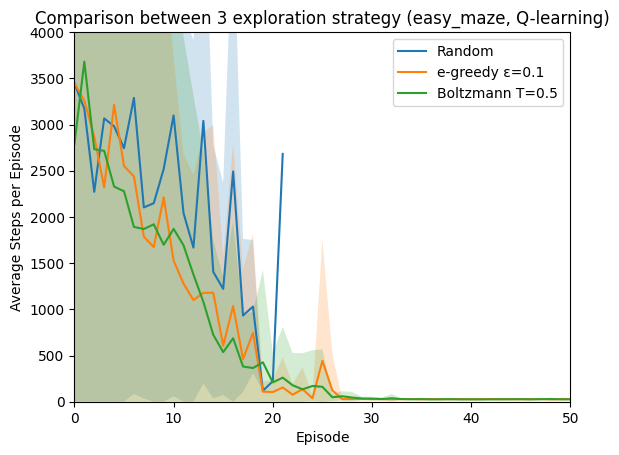

In [15]:
data = {
    "Random": run_multiple_q(easy_maze, strategy="random", n_runs=100),
    "e-greedy ε=0.1": run_multiple_q(easy_maze, strategy="e_greedy", eps=0.1, n_runs=100),
    "Boltzmann T=0.5": run_multiple_q(easy_maze, strategy="boltzmann", temperature=0.5, n_runs=100),
}

plot_comparison(data, "Comparison between 3 exploration strategy (easy_maze, Q-learning)")

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 12

In [16]:
all_data = {}

for a in [0.01, 0.1, 0.3, 0.7, 0.99]:
    all_data[f"α={a}"] = run_multiple_q(easy_maze, early_stop=30000, strategy="e_greedy", eps=0.3, params={"lr": a, "gamma": 0.9}, n_runs=100)

plot_comparison(all_data, "Comparison of alpha (easy_maze, e-greedy, Q-learning)")

# alpha = [0.01, 0.1, 0.3, 0.7, 0.99]

# for a in alpha:
#     data = run_multiple_q(toy_maze, early_stop = 30000, strategy="e_greedy", eps=0.3, params={"lr": a, "gamma": 0.9})
#     plot_average_episode_lengths(data, "toy", learning_type=f" α={a} in Q-learning")

KeyboardInterrupt: 

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.3 Introducing More Rewards
#### Question 13

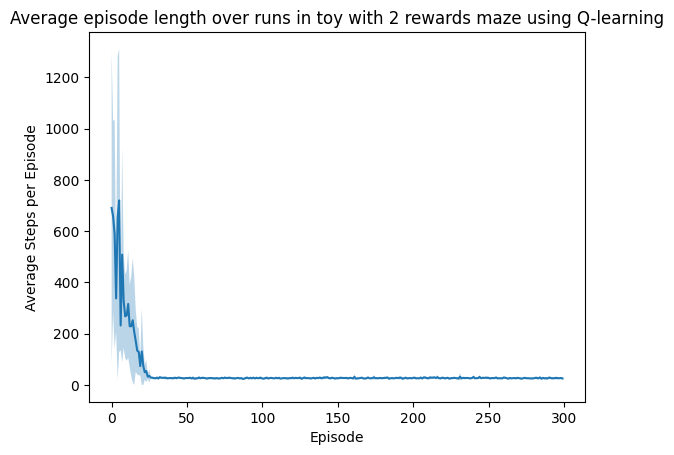

In [17]:
toy_maze = Maze("./../data/toy_maze.txt")
toy_maze.set_reward(x=9, y=9, reward=10)
toy_maze.set_terminal(x=9, y=9)

toy_maze.set_reward(x=9, y=0, reward=5)
toy_maze.set_terminal(x=9, y=0)

results = run_multiple_q(
    maze=toy_maze,
    n_runs=10,
    params={"lr": 0.7, "gamma": 0.9},
    eps=0.1,
    early_stop=100000,
    q_learning=True,
    strategy="e_greedy"
)

plot_average_episode_lengths(results, "toy with 2 rewards", "Q-learning")

I see that the average steps per episode is high but rapidly declining till around 25 episodes. After that, it smooths out at a low value. I believe this is so as the model has already recognised a policy to utilise when faced with two rewards.

#### Question 14

Q learning is an algorithm that updates its Q values based on maximising the possible future reward. This ensures that it always take the optimal action. Sarsa on the other hand updates its Q values based on the action taken under the current policy. Q learning as a result tends to learn more greedy/optimal policies. Switching to Sarsa would not lead to the agent performing better as it would prioritise close by rewards.

#### Question 15

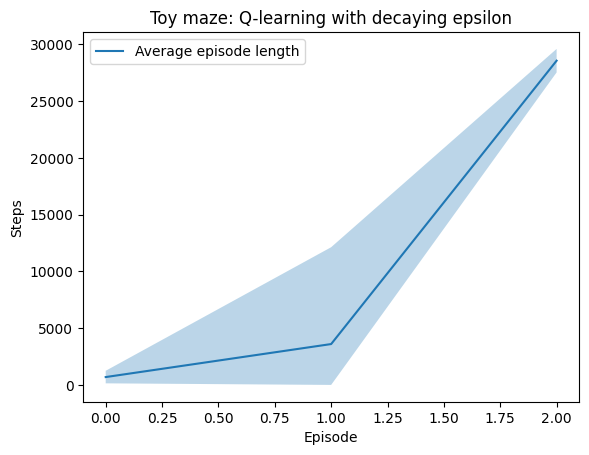

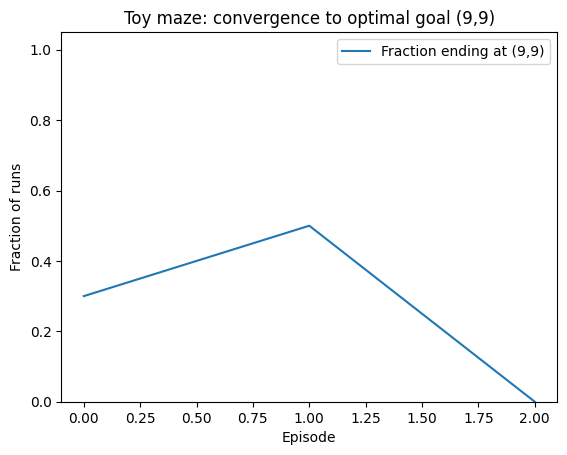

In [20]:
def main_early_stop_scheduled_eps(maze, n_episodes=300, params={"lr": 0.7, "gamma": 0.9}, eps_start=1.0, eps_min=0.05, eps_decay=0.99, early_stop=30000):
    episode_lengths = []
    episode_rewards = []
    episode_goal_is_optimal = [] 

    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)

    exploration_strategy = ExplorationStrategy(q_table)
    learner = QLearning(q_table, params)

    total_steps = 0
    eps = eps_start

    for episode in range(n_episodes):
        agent.reset()

        steps = 0
        total_r = 0
        reached_optimal = 0

        while agent.get_state(maze).done == False:
            if total_steps >= early_stop:
                break

            current_state = agent.get_state(maze)

            # use scheduled epsilon here
            chosen_action = exploration_strategy.e_greedy(agent, maze, eps)
            next_state, r, done = agent.step(chosen_action, maze)

            learner.learn(
                agent.get_valid_actions(maze),
                current_state,
                chosen_action,
                next_state,
                r,
                done
            )

            if done and (next_state.x, next_state.y) == (9, 9):
                reached_optimal = 1

            total_r += r
            steps += 1
            total_steps += 1

        episode_lengths.append(steps)
        episode_rewards.append(total_r)
        episode_goal_is_optimal.append(reached_optimal)

        eps = max(eps_min, eps * eps_decay)

        if total_steps >= early_stop:
            break

    return episode_lengths, episode_rewards, episode_goal_is_optimal

def run_multiple_q_scheduled_eps(maze, n_runs=10, params={"lr": 0.7, "gamma": 0.9}, eps_start=1.0, eps_min=0.05, eps_decay=0.99, early_stop=30000):
    all_lengths = []
    all_rewards = []
    all_optimal = []

    for _ in range(n_runs):
        lengths, rewards, optimal = main_early_stop_scheduled_eps(maze=maze, n_episodes=300, params=params, eps_start=eps_start, eps_min=eps_min, eps_decay=eps_decay, early_stop=early_stop)
        all_lengths.append(lengths)
        all_rewards.append(rewards)
        all_optimal.append(optimal)

    return all_lengths, all_rewards, all_optimal

def plot_avg_lengths(all_runs, title):
    max_len = max(len(run) for run in all_runs)
    padded = [run + [np.nan] * (max_len - len(run)) for run in all_runs]
    padded = np.array(padded)

    avg = np.nanmean(padded, axis=0)
    std = np.nanstd(padded, axis=0)
    episodes = np.arange(len(avg))

    plt.figure()
    plt.plot(episodes, avg, label="Average episode length")
    plt.fill_between(
        episodes,
        np.maximum(avg - std, 0),
        avg + std,
        alpha=0.3
    )
    plt.xlabel("Episode")
    plt.ylabel("Steps")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_optimal_goal_fraction(all_optimal_runs, title):
    max_len = max(len(run) for run in all_optimal_runs)
    padded = [run + [np.nan] * (max_len - len(run)) for run in all_optimal_runs]
    padded = np.array(padded, dtype=float)

    frac_optimal = np.nanmean(padded, axis=0)
    episodes = np.arange(len(frac_optimal))

    plt.figure()
    plt.plot(episodes, frac_optimal, label="Fraction ending at (9,9)")
    plt.xlabel("Episode")
    plt.ylabel("Fraction of runs")
    plt.ylim(0, 1.05)
    plt.title(title)
    plt.legend()
    plt.show()

toy_maze = Maze("./../data/toy_maze.txt")
toy_maze.set_reward(x=9, y=9, reward=10)
toy_maze.set_terminal(x=9, y=9)

toy_maze.set_reward(x=9, y=0, reward=5)
toy_maze.set_terminal(x=9, y=0)

all_lengths, all_rewards, all_optimal = run_multiple_q_scheduled_eps(
    maze=toy_maze,
    n_runs=10,
    params={"lr": 0.7, "gamma": 0.9},
    eps_start=1.0,
    eps_min=0.05,
    eps_decay=0.99,
    early_stop=30000
)

plot_avg_lengths(all_lengths, "Toy maze: Q-learning with decaying epsilon")
plot_optimal_goal_fraction(all_optimal, "Toy maze: convergence to optimal goal (9,9)")

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

## 3. Open Questions
### 3.1 Reflection
#### Question 17

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 18

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer here._

### 3.2 Pen and Paper
#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

#### Question 22

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

### 3.3 Division of Work

#### Question 23

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**